<a href="https://colab.research.google.com/github/DavidOprea/LiftScope/blob/machine-learning-model/Gym_Classification_Model_LiftScope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -Uqq fastbook
import fastbook
from fastbook import *
!pip install fastprogress==1.0.3
!pip install fastai==2.7.13

  Using cached fastai-2.7.13-py3-none-any.whl.metadata (9.6 kB)
  Using cached fastcore-1.5.55-py3-none-any.whl.metadata (3.5 kB)
INFO: pip is looking at multiple versions of fastai to determine which version is compatible with other requirements. This could take a while.
ERROR: Could not find a version that satisfies the requirement torch<2.2,>=1.10 (from fastai) (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch<2.2,>=1.10


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# Copy your two hand-curated folders from Drive:
#   Gym_Machines_Better_Train  -> becomes train/
#   Gym_Machines_Better_Eval   -> becomes valid/  (will be converted from HEIC below)
!cp -r "/content/drive/MyDrive/Gym_Machines_Better_Train" "/content/"
!cp -r "/content/drive/MyDrive/Gym_Machines_Better_Eval"  "/content/"

!ls -la "/content/"

Mounted at /content/drive
total 28
drwxr-xr-x  1 root root 4096 Apr  8 18:06 .
drwxr-xr-x  1 root root 4096 Apr  8 17:57 ..
drwxr-xr-x  4 root root 4096 Apr  2 13:31 .config
drwx------  6 root root 4096 Apr  8 18:03 drive
drwx------ 12 root root 4096 Apr  8 18:08 Gym_Machines_Better_Eval
drwx------ 12 root root 4096 Apr  8 18:05 Gym_Machines_Better_Train
drwxr-xr-x  1 root root 4096 Apr  2 13:31 sample_data


In [ ]:
!pip install pillow_heif Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 24.2 MB/s eta 0:00:00


In [ ]:
from PIL import Image
import pillow_heif
import os

pillow_heif.register_heif_opener()

'''
IPhone images are originall in the HEIC format and our model
doesn't use that format, so we convert them to JPEG.
'''

def convert_heic_to_jpg(input_file, output_file):
    try:
        image = Image.open(input_file)
        if image.mode != "RGB":
            image = image.convert("RGB")
        image.save(output_file, format="JPEG")
    except Exception as e:
        print(f"Error converting {input_file}: {e}")

base_path = "/content/Gym_Machines_Better_Eval"
add_path  = "/content/Gym_Machines_Better_Eval_Good"

for cls in os.listdir(base_path):
    os.makedirs(os.path.join(add_path, cls), exist_ok=True)

for cls in os.listdir(base_path):
    folder = os.path.join(base_path, cls)
    for img in os.listdir(folder):
        src  = os.path.join(folder, img)
        dst  = os.path.join(add_path, cls, img.split(".")[0] + ".jpg")
        convert_heic_to_jpg(src, dst)

print("Done converting eval images.")

Done converting eval images.


In [ ]:
import shutil
from pathlib import Path

# Create the training and validation folders

train_src = Path("/content/Gym_Machines_Better_Train")
valid_src  = Path("/content/Gym_Machines_Better_Eval_Good")
dest       = Path("/content/Gym_Machines_Data")

for class_folder in train_src.iterdir():
    if not class_folder.is_dir():
        continue
    out = dest / "train" / class_folder.name
    out.mkdir(parents=True, exist_ok=True)
    for img in class_folder.iterdir():
        shutil.copy(str(img), str(out / img.name))

for class_folder in valid_src.iterdir():
    if not class_folder.is_dir():
        continue
    out = dest / "valid" / class_folder.name
    out.mkdir(parents=True, exist_ok=True)
    for img in class_folder.iterdir():
        shutil.copy(str(img), str(out / img.name))

# Verify the layout looks right
print("Sample structure:")
for p in sorted(dest.glob("*/*"))[:12]:
    count = len(list(p.iterdir())) if p.is_dir() else "(file)"
    print(f"  {p}  ->  {count} images")

Sample structure:
  /content/Gym_Machines_Data/train/Ab Crunch Machine  ->  94 images
  /content/Gym_Machines_Data/train/Assisted Pull Up  ->  98 images
  /content/Gym_Machines_Data/train/Bench Press  ->  97 images
  /content/Gym_Machines_Data/train/Cable Machine  ->  162 images
  /content/Gym_Machines_Data/train/Hack Squat  ->  129 images
  /content/Gym_Machines_Data/train/Hyper Extension Machine  ->  130 images
  /content/Gym_Machines_Data/train/Lat Pulldown  ->  89 images
  /content/Gym_Machines_Data/train/Lying Leg Curl  ->  98 images
  /content/Gym_Machines_Data/train/Smith Machine  ->  116 images
  /content/Gym_Machines_Data/train/Treadmill  ->  91 images
  /content/Gym_Machines_Data/valid/Ab Crunch Machine  ->  55 images
  /content/Gym_Machines_Data/valid/Assisted Pull Up  ->  48 images


In [ ]:
# Build out the data preprocessing of our images

gym_equipments_block = DataBlock(
    blocks=(ImageBlock(cls=PILImage), CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='train', valid_name='valid'),
    get_y=parent_label,
    item_tfms=Resize(460, "squish"),
    batch_tfms=[*aug_transforms(size=224, mult=1.0, min_scale=0.75)]
)

path = "/content/Gym_Machines_Data"
dls  = gym_equipments_block.dataloaders(path, num_workers=2)

print(f"Classes ({dls.c}): {dls.vocab}")

Classes (10): ['Ab Crunch Machine', 'Assisted Pull Up', 'Bench Press', 'Cable Machine', 'Hack Squat', 'Hyper Extension Machine', 'Lat Pulldown', 'Lying Leg Curl', 'Smith Machine', 'Treadmill']


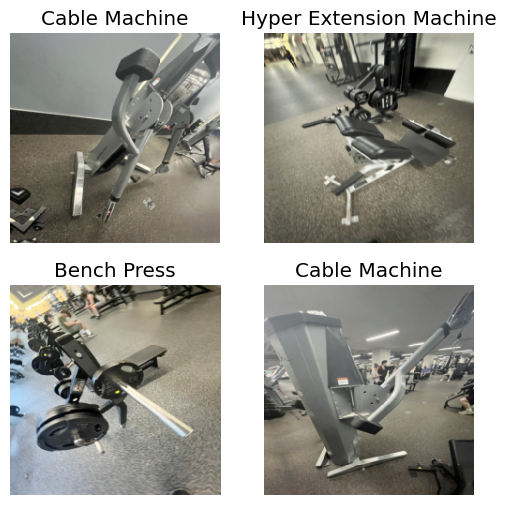

In [ ]:
dls.show_batch(max_n=4)

In [ ]:
# Create and train the model

!pip install timm

import timm
learn = vision_learner(dls, 'mobilenetv3_large_100', metrics=accuracy)

learn.fine_tune(4, freeze_epochs=2, base_lr=0.001)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,accuracy,time
0,2.700795,1.191465,0.596958,10:37
1,1.456426,0.287991,0.901141,11:20


epoch,train_loss,valid_loss,accuracy,time
0,0.194032,0.237820,0.922053,11:06
1,0.142459,0.183817,0.944867,10:25
2,0.112240,0.158156,0.944867,10:54
3,0.098663,0.155975,0.950570,11:08


In [ ]:
preds, targs = learn.tta()
print("TTA Accuracy:", accuracy(preds, targs))

TTA Accuracy: TensorBase(0.9639)


In [ ]:
# .pkl exports, in case you want to use the model in a different Python file.

learn.export('purdue_gym_model.pkl')

from google.colab import files
files.download('purdue_gym_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Libraries used to export a tflite for the model

!pip install onnx onnxscript onnxruntime onnx2tf tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB

In [ ]:
import torch
import torch.nn as nn

# Exporting the ONNX file and changing the how the model
# is exported so React Native understands how it works.

class ONNXSafeConcatPool(nn.Module):
    def forward(self, x):
        # keepdim=False collapses H and W immediately -> [B, C]
        ap = torch.mean(x, dim=[-2, -1], keepdim=False)
        mp = torch.amax(x, dim=[-2, -1], keepdim=False)
        return torch.cat([mp, ap], dim=1)  # -> [B, 2C]

class MobileReadyModel(nn.Module):
    def __init__(self, core_model):
        super().__init__()
        self.core_model = core_model
        # Patch FastAI pooling layer
        self.core_model[1][0] = ONNXSafeConcatPool()
        # Patch FastAI dynamic Flatten with a static one
        self.core_model[1][1] = nn.Flatten(start_dim=1)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.core_model(x)
        return self.softmax(x)

base_model   = learn.model.eval()
mobile_model = MobileReadyModel(base_model).cpu()
dummy_input  = torch.randn(1, 3, 224, 224).cpu()

torch.onnx.export(
    mobile_model,
    dummy_input,
    "gym_model_mobile.onnx",
    export_params=True,
    opset_version=14,
    input_names=['input'],
    output_names=['output'],
)
print("ONNX export done.")

/tmp/ipykernel_540/3530467726.py:29: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(
W0408 19:39:33.658000 540 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0408 19:39:35.341000 540 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned:

[torch.onnx] Obtain model graph for `MobileReadyModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileReadyModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
Applied 92 of general pattern rewrite rules.
ONNX export done.


In [ ]:
!onnx2tf -i gym_model_mobile.onnx -o gym_model_tflite -b 1
print("TFLite conversion done.")


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃                    ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add                │ 10             │ 10               │
│ BatchNormalization │ 2              │ 2                │
│ Concat             │ 1              │ 1                │
│ Constant           │ 136            │ 136              │
│ Conv               │ 62             │ 62               │
│ Gemm               │ 2              │ 2                │
│ HardSigmoid        │ 8              │ 8                │
│ HardSwish          │ 20             │ 20               │
│ Mul                │ 8              │ 8                │
│ ReduceMax          │ 1              │ 1                │
│ ReduceMean         │ 9              │ 9                │
│ Relu               │ 20             │ 